# Multi-objective optimization

This notebook demonstrates how to perform **multi-objective** Bayesian optimization using the MO-SEGO (Multi-Objective Super Efficient Global Optimization) framework. Constrained and multi-fidelity optimization are also supported in the multi-objective framework.

In multi-objective optimization, we are interested in minimizing multiple $n$ objectives with respect to constraints $\boldsymbol{g}$ and $\boldsymbol{h}$ (if applicable).

$$
\min_{\boldsymbol{x} \in \Omega} \{ \boldsymbol{f}(\boldsymbol{x}) := [ f_1(\boldsymbol{x}), \; f_1(\boldsymbol{x}), \; \dots, \; f_n(\boldsymbol{x})]  \quad \text{s.t.} \quad \boldsymbol{g}(\boldsymbol{x}) \leq \boldsymbol{0} \; \text{and} \; \boldsymbol{h}(\boldsymbol{x}) = \boldsymbol{0}\}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtGPX,SmtAutoModel

from smt_optim.acquisition_strategies.mosego import MOSEGO
from smt_optim.acquisition_functions import init_ehvi_2o, init_mpi
from smt_optim.utils.multi_obj import get_pf_from_dataset

from smt_optim.benchmarks.registry import get_problem

from smt_optim.utils.multi_obj import PymooStateWrapper
from smt_optim.benchmarks.base import PymooWrapper
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize


## Multi-objective optimization

The following example illustrates how to find the ZDT1's Pareto front using the MO-SEGO framework. The code cell below imports the test problem using the `get_problem` method and plots both objective. The ZDT1 is defined as follows:

$$
\begin{aligned}
f_1(\boldsymbol x) & = x_1\\
f_2(\boldsymbol x) & = g(\boldsymbol x) h(f_1(\boldsymbol x), \; g(\boldsymbol x))
\end{aligned}
$$

where $d=2$ is the number of variables, $g(\boldsymbol x) = 1 + \frac{9}{d - 1}\sum_{i=2}^{d}x_i$, and $h(f_1, \; g) = 1 - \sqrt{f_1/g}$.



In [2]:

problem = get_problem("ZDT1")
problem.set_dim(2)


### Starting the optimization

The code cell shows how to initialize both objectives, the problem configuration, and the driver configuration. The driver is initialized with the `MOSEGO` acquisition strategy, which is designed for multiple objective optimization. The **Expected Hypervolume Improved (EHVI)** acquisition function is used in this example.


In [3]:
# initialize the first objective configuration
obj1_config = ObjectiveConfig(
    [problem.f1],
    type="minimize",
    surrogate=SmtGPX,
)

# initialize the second objective configuration
obj2_config = ObjectiveConfig(
    [problem.f2],
    type="minimize",
    surrogate=SmtGPX,
)

# initialize the problem configuration
prob_definition = Problem(
    obj_configs=[obj1_config, obj2_config],
    design_space=problem.bounds,
)

nt_init = 5

# initialize the driver
opt_config = DriverConfig(
    max_iter = 20,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

driver = Driver(prob_definition, opt_config, MOSEGO, strategy_kwargs={"acq_init": init_ehvi_2o,})

# starts the optimization process
state = driver.optimize()


          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              5    4.19380e+00    1.51008e+00            nan            nan            nan
             1              6    6.03242e+00    0.00000e+00              1          0.048          0.255
             2              7    6.25985e+00    0.00000e+00              1          0.036          0.393
             3              8    6.31537e+00    3.16323e-01              1          0.053          0.388
             4              9    6.39117e+00    9.35584e-02              1          0.057          0.339
             5             10    6.40787e+00    1.17325e-01              1          0.054          0.313
             6             11    6.43222e+00    6.34793e-02              1          0.044          0.332
             7             12    6.44228e+00    6.06331e-02              1          0.042          0.396
             8             13    6.45186e+00    6.14440

### Plotting the results

The code cell below extracts the Pareto front (PF) from the final DOE using the `get_pf_from_dataset` method. The figure shows the final DOE, the initial DOE, and compares the Pareto front obtained with MO-SEGO with one obtained with Pymoo's NSGA-II algorithm.


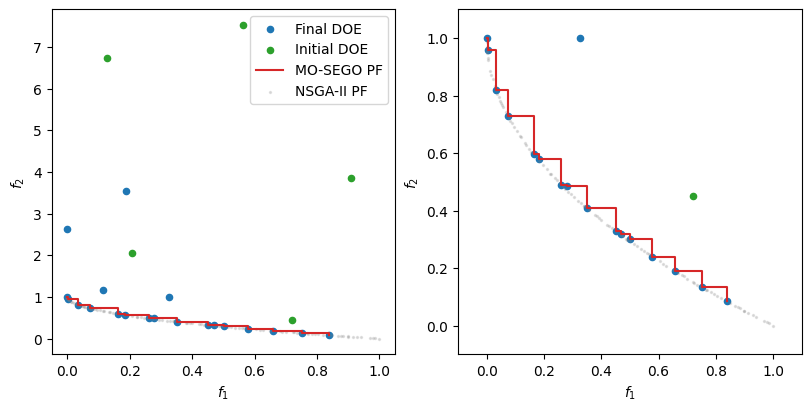

In [4]:

# ======= MO-SEGO Pareto Front =======
data = driver.state.dataset.export_as_dict()
obj = data["obj"]

obj_par = get_pf_from_dataset(state.dataset)
sorted_idx = np.argsort(obj_par[:, 0])
obj_par = obj_par[sorted_idx, :]

# ======= NSGA-II Pareto Front =======
pymoo_problem = PymooWrapper(problem)

# find the Pareto front with Pymoo's NSGA-II implementation
algorithm = NSGA2(pop_size=100, seed=0)
pymoo_res = minimize(pymoo_problem, algorithm, ("n_gen", 100), seed=0)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

for i in range(2):
    ax[i].scatter(obj[nt_init:, 0], obj[nt_init:, 1], 20, color="C0", label="Final DOE")
    ax[i].scatter(obj[:nt_init, 0], obj[:nt_init, 1], 20, color="C2", label="Initial DOE")

    # PF obtained through optimization
    ax[i].step(obj_par[:, 0], obj_par[:, 1], where="post", color="C3", zorder=20, label="MO-SEGO PF")

    # NSGA-II PF
    ax[i].scatter(pymoo_res.F[:, 0], pymoo_res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10, label="NSGA-II PF")

    ax[i].set_xlabel(r"$f_1$")
    ax[i].set_ylabel(r"$f_2$")

ax[1].set_xlim((-0.1, 1.1))
ax[1].set_ylim((-0.1, 1.1))
ax[0].legend()
plt.show()


## Constrained multi-objective optimization

The following example illustrates how to find the Pareto front when subjected to constraints. The `get_problem` method is used to import the BNH test problem, which is defined as follows:

$$
\begin{aligned}
f_1(\boldsymbol x) & = 4x_1^2 + 4x_2^2\\
f_2(\boldsymbol x) & = (x_1 - 5)^2 + (x_2 - 5)^2\\
g_1(\boldsymbol x) & = (x_1 - 5)^2 + x_2^2 - 25\\
g_2(\boldsymbol x) & = -(x_1 - 8)^2 - (x_2^2+3)^2 + 7.7.
\end{aligned}
$$


In [5]:
problem = get_problem("BNH")


### Starting the optimization

The code cell shows how to initialize both objectives, the constraints, the problem configuration, and the driver configuration.



In [6]:

obj1_config = ObjectiveConfig(
    [problem.objective[0]],
    type="minimize",
    surrogate=SmtGPX,
)

obj2_config = ObjectiveConfig(
    [problem.objective[1]],
    type="minimize",
    surrogate=SmtGPX,
)

cstr1_config = ConstraintConfig(
    [problem.constraints[0]],
    upper=0.,
    surrogate=SmtGPX,
)

cstr2_config = ConstraintConfig(
    [problem.constraints[1]],
    upper=0.,
    surrogate=SmtGPX,
)

prob_definition = Problem(
    obj_configs=[obj1_config, obj2_config],
    cstr_configs=[cstr1_config, cstr2_config],
    design_space=problem.bounds,            # problem bounds
)

nt_init = 5

opt_config = DriverConfig(
    max_iter = 20,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

driver = Driver(prob_definition, opt_config, MOSEGO,)

state = driver.optimize()


          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0              5    1.12241e+03    3.97964e+00            nan            nan            nan
             1              6    1.32685e+03    3.61912e+00              1          0.074          0.433
             2              7    1.42727e+03    7.43670e+00              1          0.070          0.446
             3              8    1.49829e+03    6.21611e+00              1          0.095          0.445
             4              9    1.56072e+03    4.17312e+00              1          0.097          0.440
             5             10    1.59259e+03    3.69643e+00              1          0.092          0.450
             6             11    1.62381e+03    1.94212e+00              1          0.094          0.542
             7             12    1.65345e+03    1.77586e+00              1          0.108          0.764
             8             13    1.67080e+03    1.60725

### Plotting the results

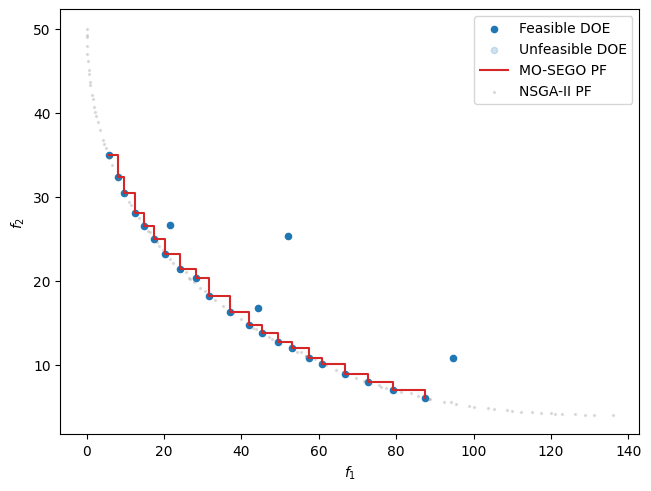

In [7]:
# ======= MO-SEGO Pareto Front =======
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
feas_mask = data["rscv"] <= 1e-4

obj_par = get_pf_from_dataset(state.dataset)
sorted_idx = np.argsort(obj_par[:, 0])
obj_par = obj_par[sorted_idx, :]

# ======= NSGA-II Pareto Front =======
pymoo_problem = PymooWrapper(problem)

# find the Pareto front with Pymoo's NSGA-II implementation
algorithm = NSGA2(pop_size=100, seed=0)
pymoo_res = minimize(pymoo_problem, algorithm, ("n_gen", 100), seed=0)

# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots(layout="constrained")

ax.scatter(obj[feas_mask, 0], obj[feas_mask, 1], 20, color="C0", label="Feasible DOE")
ax.scatter(obj[~feas_mask, 0], obj[~feas_mask, 1], 20, color="C0", alpha=0.2, label="Unfeasible DOE")

# PF obtained through optimization
ax.step(obj_par[:, 0], obj_par[:, 1], where="post", color="C3", zorder=20, label="MO-SEGO PF")

# Solution PF
ax.scatter(pymoo_res.F[:, 0], pymoo_res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10, label="NSGA-II PF")

ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")

ax.legend()
plt.show()


### Applying NSGA-II (Pymoo) on the surrogate models

Users can use the `PymooStateWrapper` to convert a state object into a `Pymoo` `Problem` object. Below, the NSGA-II algorithm is applied on the objective and constraint models to find a predicted Pareto front.


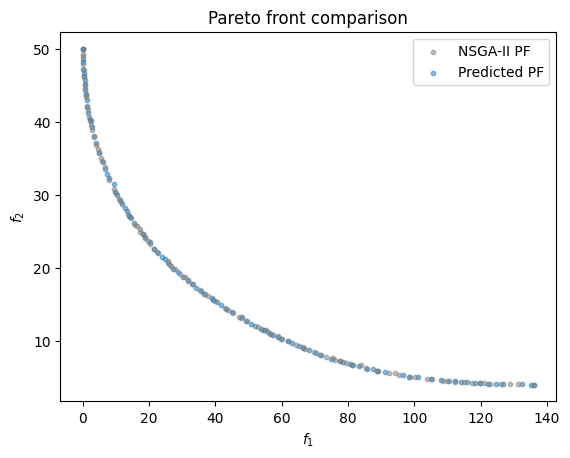

In [8]:

# Create a pymoo problem object from the SMT-Optim state object
pymoo_state = PymooStateWrapper(state)

algorithm = NSGA2(pop_size=100, seed=1)
state_res = minimize(pymoo_problem, algorithm, ("n_gen", 100), seed=1)

fig, ax = plt.subplots()

ax.scatter(pymoo_res.F[:, 0], pymoo_res.F[:, 1], 10, color="C7", alpha=0.5, zorder=10, label="NSGA-II PF")

ax.scatter(state_res.F[:, 0], state_res.F[:, 1], 10, color="C0", alpha=0.5, label="Predicted PF")

ax.legend()
ax.set_title("Pareto front comparison")
ax.set_xlabel(r"$f_1$")
ax.set_ylabel(r"$f_2$")
plt.show()


## Constrained, multi-fidelity, and multi-objective optimization

The following example demonstrates how to find the Pareto front of a constrained multi-objective problem, for which low-fidelity approximations exist.

This example uses the `DTLZ5` test function which has 2 fidelity levels and 1 constraint.

The code cell below imports the `DTLZ5` test function, initializes the objectives, the constraint, the problem configuration, and the driver configuration, and starts the optimization process.


### Starting the optimization






In [9]:
problem = get_problem("DTLZ5")
problem.set_dim(4)

obj_config = ObjectiveConfig(
    problem.objective[0],
    type="minimize",
    surrogate=SmtAutoModel,
)

obj_config2 = ObjectiveConfig(
    problem.objective[1],
    type="minimize",
    surrogate=SmtAutoModel,
)

cstr_config = ConstraintConfig(
    problem.constraints[0],
    upper=0.,
    surrogate=SmtAutoModel,
)

prob_definition = Problem(
    obj_configs=[obj_config, obj_config2],
    cstr_configs=[cstr_config],
    design_space=problem.bounds,
    costs=[0.2, 1.],
)

nt_init = 12

opt_config = DriverConfig(
    max_iter = 20,
    nt_init = nt_init,
    verbose = True,
    scaling = True,
    seed=0,
)

driver = Driver(prob_definition, opt_config, MOSEGO)
state = driver.optimize()


          iter         budget             HV        spacing       fidelity        gp_time       acq_time
             0         16.800    2.01117e-01    0.00000e+00            nan            nan            nan
             1         17.000    2.01117e-01    0.00000e+00              1          1.654          4.670
             2         17.200    2.01117e-01    0.00000e+00              1          1.369          5.223
             3         17.400    2.01117e-01    0.00000e+00              1          1.419          5.676
             4         17.600    2.01117e-01    0.00000e+00              1          1.451          5.474
             5         18.800    2.72241e-01    1.33011e-01              2          1.351          4.988
             6         19.000    2.72241e-01    1.33011e-01              1          1.373          3.521
             7         19.200    2.72241e-01    1.33011e-01              1          1.355          2.551
             8         19.400    2.72241e-01    1.33011

### Plotting the results

The code cell below extracts the Pareto front from the final DOE using the `get_pf_from_dataset` method. The figure shows the low- (LF) and high-fidelity (HF) DOE. Moreover, the Pareto front obtained with MO-SEGO is compared to the one obtained with NSGA-II.


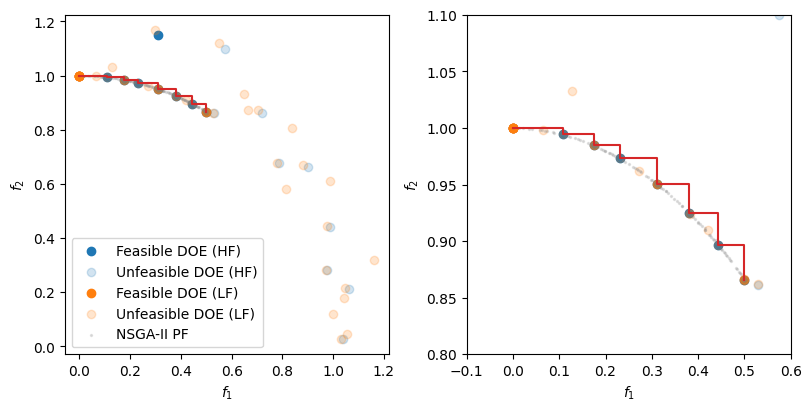

In [10]:

# ======= MO-SEGO Pareto Front =======
data = driver.state.dataset.export_as_dict()
obj = data["obj"]
rscv = data["rscv"]
feas_mask = rscv <= 1e-4
fid_mask = data["fidelity"] == 1

pareto_front = get_pf_from_dataset(state.dataset)
sorted_idx = np.argsort(pareto_front[:, 0])
pareto_front = pareto_front[sorted_idx, :]

# ======= NSGA-II Pareto Front =======
pymoo_problem = PymooWrapper(problem)

# find the Pareto front with Pymoo's NSGA-II implementation
algorithm = NSGA2(pop_size=100, seed=0)
pymoo_res = minimize(pymoo_problem, algorithm, ("n_gen", 100), seed=0)


# ======= Plot optimization and solution pareto front =======
fig, ax = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

for i in range(2):
    ax[i].scatter(obj[:, 0][feas_mask & fid_mask], obj[:, 1][feas_mask & fid_mask], color="C0", label="Feasible DOE (HF)")
    ax[i].scatter(obj[:, 0][~feas_mask & fid_mask], obj[:, 1][~feas_mask & fid_mask], color="C0", alpha=0.2, label="Unfeasible DOE (HF)")
    ax[i].scatter(obj[:, 0][feas_mask & ~fid_mask], obj[:, 1][feas_mask & ~fid_mask], color="C1", label="Feasible DOE (LF)")
    ax[i].scatter(obj[:, 0][~feas_mask & ~fid_mask], obj[:, 1][~feas_mask & ~fid_mask], color="C1", alpha=0.2, label="Unfeasible DOE (LF)")

    # MO-SEGO PF
    ax[i].step(pareto_front[:, 0], pareto_front[:, 1], where="post", color="C3", zorder=20)

    # NSGA-II PF
    ax[i].scatter(pymoo_res.F[:, 0], pymoo_res.F[:, 1], 2, color="C7", alpha=0.2, zorder=10, label="NSGA-II PF")

    ax[i].set_xlabel(r"$f_1$")
    ax[i].set_ylabel(r"$f_2$")


ax[0].legend()
ax[1].set_xlim([-0.1, 0.6])
ax[1].set_ylim([0.8, 1.1])

plt.show()
